<a href="https://colab.research.google.com/github/tttslab/speech-information-technology/blob/main/voicechanger/voicechanger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Google Colab環境かどうかを判定
if 'google.colab' in str(get_ipython()):
    # リポジトリがまだなければクローン
    if not os.path.exists('speech-information-technology'):
        !git clone https://github.com/tttslab/speech-information-technology.git

    # 作業ディレクトリをvoicechangerに移動
    # これにより、'samplewav/xxx.wav' という相対パスがそのまま通るようになります
    os.chdir('speech-information-technology/voicechanger')
    print(f"Current directory: {os.getcwd()}")

Cloning into 'speech-information-technology'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 58 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 1.68 MiB | 13.22 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Current directory: /content/speech-information-technology/voicechanger


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
import math as mt

# 16kHz / 16bit PCM 向けの設定
FS = 16000

def splitwave(wav, wlen, shft):
    T = mt.floor((np.size(wav) - wlen) / shft + 1)
    wframes = np.zeros([T, wlen])
    for t in range(0, T):
        wframes[t, :] = wav[t * shft : t * shft + wlen] * np.hanning(wlen)
    return wframes

def concatwframes(wframes, shft):
    [T, wlen] = np.shape(wframes)
    wavout = np.zeros([(T - 1) * shft + wlen])
    for t in range(0, T):
        wavout[shft * t : shft * t + wlen] += wframes[t, :]
    return wavout

Processing: Source=samplewav/sawtooth100hz.wav, Filter=samplewav/toukoudai.wav
### Original Source (音源) ###


### Original Filter (声質) ###


### Synthesized Result (再合成結果: N=15) ###


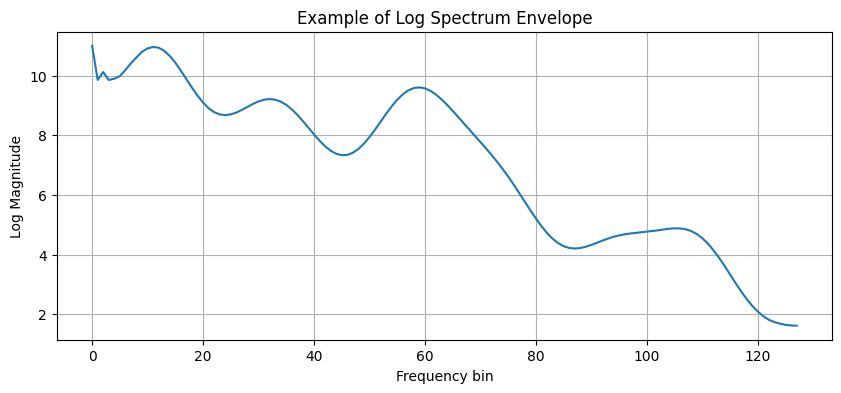

In [3]:
# --- パラメータ設定 ---
window = 256
shift = 128
N = 15  # ケプストラムの次数（境界点）

# --- ファイル選択（コメントを外して選択してください） ---

# ソース（音源情報）の選択
wavS_file = 'samplewav/sawtooth100hz.wav'
# wavS_file = 'samplewav/sawtooth300hz.wav'
# wavS_file = 'samplewav/noise1.wav'

# フィルター（スペクトル包絡・声質）の選択
wavF_file = 'samplewav/toukoudai.wav'
# wavF_file = 'samplewav/neorock38.wav'

# --- 処理開始 ---
print(f"Processing: Source={wavS_file}, Filter={wavF_file}")

# 読み込み
rateS, s = wavfile.read(wavS_file)
rateF, f = wavfile.read(wavF_file)

# 短い方に合わせる
minlen = min(np.size(s), np.size(f))
s, f = s[0:minlen], f[0:minlen]

# フレーム分割
wSframes = splitwave(s, window, shift)
wFframes = splitwave(f, window, shift)

# スペクトル算出
specS = np.fft.fft(wSframes)
specF = np.fft.fft(wFframes)

# ケプストラム分析
# log(abs)をとる際、0によるエラーを避けるため微小値を加算
cepS = np.fft.ifft(np.log(np.abs(specS) + 1e-10))
cepF = np.fft.ifft(np.log(np.abs(specF) + 1e-10))

# 再合成ケプストラムの作成
cepY = np.zeros(np.shape(cepS), dtype="complex")
# 高次成分（Sourceから抽出：音源・ピッチ情報）
cepY[:, (N+1):(window-N)] = cepS[:, (N+1):(window-N)]
# 低次成分（Filterから抽出：声道特性・フォルマント情報）
cepY[:, 0:N+1] = cepF[:, 0:N+1]
cepY[:, window-N:window] = cepF[:, window-N:window]

# 波形に戻す
specYamp = np.exp(np.real(np.fft.fft(cepY)))
specY = specYamp * np.exp(np.angle(specS) * 1j)  # Sourceの位相を保持

wYframes = np.real(np.fft.ifft(specY))
wavout = concatwframes(wYframes, shift).astype(np.int16)

# --- 結果の表示と再生 ---
print("### Original Source (音源) ###")
display(Audio(wavS_file))

print("### Original Filter (声質) ###")
display(Audio(wavF_file))

print(f"### Synthesized Result (再合成結果: N={N}) ###")
display(Audio(wavout, rate=FS))

# スペクトル包絡の確認（デモ用プロット）
plt.figure(figsize=(10, 4))
plt.title("Example of Log Spectrum Envelope")
plt.plot(np.log(specYamp[int(len(specYamp)/2), :window//2]))
plt.xlabel("Frequency bin")
plt.ylabel("Log Magnitude")
plt.grid(True)
plt.show()